# Proyecto Data Mining - CRISP-DM

**Integrantes:** Flavio Henriquez / Bastian Bianchi  
**Docente:** Italo Bonnet

## 1. Entendimiento del Negocio

Esta fase tiene por finalidad definir el problema de estudio, justificar su relevancia y delimitar el alcance del analisis. En coherencia con la metodologia CRISP-DM, el proposito inicial no es construir un modelo de manera inmediata, sino comprender con claridad que valor puede aportar el estudio de las precipitaciones diarias, que informacion se encuentra disponible, cuales son las principales restricciones del conjunto de datos y bajo que criterios se evaluara la pertinencia del trabajo desarrollado.


### 1.1 Contexto

Chile presenta una marcada diversidad climatica y geografica. En su territorio coexisten zonas deserticas, altiplanicas, valles interiores, sectores costeros y areas de clima mediterraneo, por lo que la precipitacion no se distribuye de manera homogenea ni en el espacio ni en el tiempo. Esta variabilidad convierte el estudio de las lluvias en un problema relevante para la gestion hidrica, la planificacion agricola, el monitoreo meteorologico, la prevencion de eventos extremos y la toma de decisiones territoriales.

El presente proyecto utiliza un dataset de precipitaciones diarias registradas por estaciones meteorologicas chilenas. La granularidad diaria resulta especialmente pertinente, ya que permite observar no solo la magnitud de la lluvia, sino tambien la frecuencia de ocurrencia de los eventos, su concentracion estacional y las diferencias existentes entre estaciones. En consecuencia, el conjunto ofrece una perspectiva mas precisa que un agregado mensual, especialmente cuando se busca identificar dias sin precipitacion, eventos intensos y patrones temporales recurrentes.

Desde una perspectiva aplicada, el valor del analisis radica en transformar registros operacionales en informacion util para comprender el comportamiento de la precipitacion y dejar una base consistente para etapas posteriores del proyecto. No obstante, tambien es necesario reconocer que el dataset no incorpora todas las variables climaticas que podrian influir en el fenomeno. Por ello, en esta primera fase el objetivo central consiste en caracterizar adecuadamente el caso, delimitar su alcance y justificar las decisiones analiticas que orientaran las siguientes etapas del trabajo.


### 1.2 Datos relevantes

El analisis se sustenta en el archivo `dataset_precipitaciones_diarias_chile_COMPLETO.csv`, que contiene la serie diaria principal, y puede complementarse con `Set de datos/getEstacionesRedEma.json`, el cual permite asociar a los codigos tecnicos nombres descriptivos de estaciones, regiones y zonas geograficas. Esta complementacion resulta relevante porque mejora la interpretacion territorial de los datos y facilita su lectura desde una perspectiva de negocio.

Con el fin de ordenar la presentacion, primero se resume el alcance general del conjunto y, a continuacion, se expone el diccionario de variables considerado en esta fase.

**Resumen del conjunto**

| Aspecto | Valor observado | Relevancia para el proyecto |
| --- | --- | --- |
| Fuente principal | `dataset_precipitaciones_diarias_chile_COMPLETO.csv` | Contiene la base diaria usada para el analisis |
| Metadata complementaria | `Set de datos/getEstacionesRedEma.json` | Permite enriquecer los codigos con nombres de estacion, region y zona geografica |
| Granularidad | 1 registro por estacion y por dia | Permite analizar frecuencia e intensidad diaria de precipitaciones |
| Periodo cubierto | 2021-01-01 a 2025-12-31 | Entrega continuidad temporal reciente de 5 anos |
| Cantidad de registros | 187,876 filas | Da volumen suficiente para detectar patrones temporales y territoriales |
| Variables originales | 10 columnas | Incluye atributos de ubicacion, tiempo y precipitacion |
| Estaciones meteorologicas | 109 | Aporta diversidad espacial y comparacion entre puntos de medicion |
| Regiones representadas | 16 | Entrega cobertura territorial amplia dentro de Chile |
| Variable objetivo | `agua_caida` | Es la magnitud que se desea comprender y eventualmente predecir |
| Nulos en `agua_caida` | 17,063 registros (9.08%) | Obliga a revisar estrategia de limpieza o imputacion antes de modelar |

Los atributos disponibles describen tanto la ubicacion de la estacion como el momento temporal exacto del registro. En consecuencia, el siguiente diccionario resume las variables base sobre las cuales se desarrolla el problema analitico.

**Diccionario de variables**

| Variable | Descripcion | Tipo analitico | Rol dentro del problema |
| --- | --- | --- | --- |
| `codigo_estacion` | Identificador de la estacion meteorologica | Categorica nominal codificada numericamente | Permite distinguir comportamiento local por estacion |
| `region` | Codigo de la region asociada a la estacion | Categorica nominal codificada numericamente | Resume pertenencia territorial |
| `altura` | Altitud de la estacion en metros | Numerica discreta | Puede influir en el patron de precipitacion |
| `latitud` | Coordenada de latitud | Numerica continua | Captura posicion geografica norte-sur |
| `longitud` | Coordenada de longitud | Numerica continua | Captura posicion geografica este-oeste |
| `anio` | Ano del registro | Numerica discreta temporal | Permite analizar cambios interanuales |
| `mes` | Mes del registro | Numerica discreta temporal | Representa estacionalidad anual |
| `dia` | Dia del mes | Numerica discreta temporal | Permite trabajar a nivel diario |
| `fecha` | Fecha completa del registro | Temporal | Facilita orden cronologico y creacion de nuevas variables |
| `agua_caida` | Milimetros de precipitacion observados en el dia | Numerica continua | Variable objetivo del analisis |

**Analisis.** La adopcion de un dataset diario modifica de manera sustantiva el alcance del problema respecto de una base agregada mensualmente. En este caso, no solo interesa describir montos acumulados, sino tambien examinar la frecuencia de los dias con precipitacion, la concentracion de eventos intensos y la continuidad temporal de cada estacion. Sobre el total de registros, el 67.68% presenta `agua_caida = 0`, el 23.24% registra precipitacion positiva y el 9.08% corresponde a valores nulos en la variable objetivo. En terminos analiticos, esta combinacion de granularidad diaria, cobertura territorial y volumen de observaciones convierte al conjunto en una base pertinente para caracterizacion descriptiva y para una eventual proyeccion predictiva posterior.


### 1.3 Hipotesis y tesis consideradas

A partir del contexto del problema y de la estructura del dataset, se plantean las siguientes hipotesis de trabajo:

- La precipitacion diaria presenta un comportamiento estacional identificable, por lo que `mes`, `fecha` y posibles variables derivadas del calendario deberian explicar una parte relevante de la variacion observada en `agua_caida`.
- La ubicacion geografica de cada estacion, representada por `latitud`, `longitud`, `altura` y `region`, influye en la intensidad y en la frecuencia de las precipitaciones.
- Existen diferencias estructurales entre estaciones meteorologicas; por lo tanto, `codigo_estacion` no solo actua como identificador, sino que tambien sintetiza condiciones locales de relieve, exposicion y microclima.
- La base diaria presenta una alta concentracion de dias sin precipitacion, por lo que la distribucion de la variable objetivo sera asimetrica y exigira especial cuidado interpretativo.
- Los valores faltantes de `agua_caida` deben revisarse antes de cualquier etapa posterior, ya que una concentracion no aleatoria por estacion o por periodo podria sesgar las conclusiones del analisis.
- Como proyeccion del proyecto, el caso puede formularse posteriormente como una tarea predictiva de regresion orientada a estimar la precipitacion diaria en milimetros.

**Analisis.** Las hipotesis propuestas son consistentes con el enfoque de CRISP-DM revisado en el material de apoyo, ya que parten desde una comprension razonada del problema antes de avanzar hacia etapas de preparacion o modelamiento. En este caso, la estacionalidad, la heterogeneidad territorial y la asimetria de la variable objetivo no constituyen detalles secundarios, sino rasgos centrales del fenomeno estudiado. Por ello, en la fase siguiente sera especialmente importante examinar la distribucion de los nulos, la capacidad explicativa de las variables disponibles y la conveniencia de construir atributos temporales o territoriales mas expresivos.


### 1.4 KPI relevantes

En una entrega centrada en las primeras fases de CRISP-DM, los KPI mas pertinentes no corresponden todavia al rendimiento de un modelo final, sino a indicadores que permitan evaluar si el problema ha sido correctamente delimitado y si la base presenta condiciones adecuadas para continuar con el proceso analitico.

| KPI | Valor o criterio actual | Por que es relevante |
| --- | --- | --- |
| Cobertura temporal del dataset | 2021-01-01 a 2025-12-31 | Confirma que el analisis abarca 5 anos recientes y no solo una temporada aislada |
| Cobertura territorial | 109 estaciones en 16 regiones | Mide si el problema tiene representatividad geografica suficiente |
| Completitud de `agua_caida` | 90.92% con dato disponible | Permite saber cuanta informacion util hay para analizar o modelar |
| Registros con `agua_caida = 0` | 67.68% del total | Advierte que la variable objetivo esta altamente concentrada en ausencia de lluvia |
| Registros con precipitacion positiva | 23.24% del total | Ayuda a dimensionar la frecuencia real de eventos de lluvia |
| Duplicados por estacion-fecha | 0 | Indica consistencia basica de la unidad de analisis diaria |

Si el proyecto avanzara hacia una etapa predictiva de regresion, las metricas tecnicas mas coherentes con lo revisado en clases serian las siguientes:

- `RMSE`, debido a que penaliza con mayor intensidad los errores elevados y se encuentra explicitamente considerado en la estructura del curso.
- `r`, porque permite evaluar el grado de asociacion entre los valores reales y los valores estimados en una futura etapa de evaluacion.

**Analisis.** Estos indicadores articulan la comprension del negocio con las decisiones tecnicas sin anticipar de manera excesiva contenidos posteriores. Por ejemplo, una base con amplia cobertura territorial pero con menor completitud en la variable objetivo puede resultar adecuada para caracterizar patrones generales, aunque no necesariamente para sustentar un modelamiento confiable sin una etapa previa de limpieza. Asimismo, en un escenario diario con alta presencia de ceros, la futura evaluacion del modelo no debiera limitarse a un promedio general de error, sino considerar tambien su comportamiento frente a episodios de precipitacion mas intensos.


### 1.5 Problema de negocio (Analisis y proyeccion predictiva)

El problema de negocio consiste en comprender y dejar preparada una base analitica que permita explicar el comportamiento de la precipitacion diaria en estaciones meteorologicas chilenas. El valor esperado del proyecto radica en aportar informacion util para la gestion hidrica, el monitoreo de condiciones climaticas, la planificacion territorial y el analisis de riesgo asociado a periodos secos o a eventos de lluvia intensa.

La unidad de analisis del proyecto corresponde a cada combinacion `estacion-dia`. En dicho nivel, la variable objetivo es `agua_caida`, medida en milimetros, mientras que las variables disponibles describen la ubicacion geografica de la estacion y el momento temporal del registro. Desde la perspectiva de mineria de datos, el caso puede proyectarse principalmente como un problema de regresion supervisada orientado a estimar la precipitacion diaria a partir de atributos espaciales y temporales.

**Analisis.** Dado que esta entrega prioriza el entendimiento del negocio y de los datos, el objetivo no consiste en prometer un modelo final, sino en formular correctamente el caso y preparar la base con criterios tecnicamente defendibles. La principal fortaleza del dataset diario es que permite pasar de una mirada agregada a una lectura mas fina del fenomeno; su principal limitacion es que no incorpora otras variables meteorologicas potencialmente explicativas. En consecuencia, cualquier desarrollo predictivo posterior debera interpretarse como una aproximacion sustentada en informacion temporal, territorial e historica. Aun con dicha restriccion, el problema se encuentra adecuadamente planteado y ofrece una base razonable para continuar con las siguientes fases del proceso.


## 2. Entendimiento de los Datos

En esta fase se realiza una exploracion estructurada del dataset con el fin de identificar tipos de variables, valores faltantes, posibles outliers, distribuciones basicas, correlaciones y patrones relevantes. En coherencia con el material de apoyo, el objetivo no es solo describir los datos, sino tambien interpretar su calidad y anticipar decisiones de preparacion que permitan continuar el proceso de mineria de datos con mayor solidez.


### 2.1 Identificar Tipos de variables/atributos


En esta subseccion se distingue entre el tipo tecnico detectado por `pandas` y el tipo analitico que realmente cumple cada atributo dentro del problema. Esta distincion es importante porque varias columnas aparecen como numericas, pero conceptualmente funcionan como identificadores o categorias nominales y, por lo tanto, no deben interpretarse como magnitudes continuas.


In [1]:
# Si necesitas instalar dependencias en este notebook:
# %pip install pandas numpy matplotlib

from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", None)


def heatmap_df(data, title, cmap="Blues", figsize=(8, 5), decimals=2):
    fig, ax = plt.subplots(figsize=figsize)
    matrix = data.astype(float).values
    im = ax.imshow(matrix, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index)
    for row in range(data.shape[0]):
        for col in range(data.shape[1]):
            value = matrix[row, col]
            ax.text(col, row, f"{value:.{decimals}f}", ha="center", va="center", fontsize=8)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()


def region_to_macrozone(region_code):
    if region_code in [15, 1, 2, 3, 4]:
        return "Norte"
    if region_code in [5, 13, 6, 7]:
        return "Centro"
    if region_code in [16, 8, 9, 14, 10]:
        return "Sur"
    if region_code in [11, 12]:
        return "Austral"
    return "Otra"


base_path = Path("dataset_precipitaciones_diarias_chile_COMPLETO.csv")
meta_path = Path("Set de datos") / "getEstacionesRedEma.json"

df_csv = pd.read_csv(base_path)
meta_json = json.loads(meta_path.read_text(encoding="utf-8"))
meta_df = (
    pd.DataFrame(meta_json["datosEstacion"])[
        ["codigoNacional", "region", "nombreEstacion", "NombreRegion", "zonaGeografica"]
    ]
    .rename(
        columns={
            "codigoNacional": "codigo_estacion",
            "nombreEstacion": "nombre_estacion",
            "NombreRegion": "nombre_region",
            "zonaGeografica": "zona_geografica",
        }
    )
    .drop_duplicates(subset=["codigo_estacion", "region"])
)

df = (
    df_csv.merge(meta_df, on=["codigo_estacion", "region"], how="left")
          .sort_values(["codigo_estacion", "fecha"])
          .reset_index(drop=True)
)
df["fecha"] = pd.to_datetime(df["fecha"])

print(f"Dimension del dataset enriquecido: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Periodo disponible: {df['fecha'].min().date()} a {df['fecha'].max().date()}")
print(f"Estaciones con metadata: {df['nombre_estacion'].nunique()}")
print(f"Regiones representadas: {df['nombre_region'].nunique()}")
display(df.head())


Dimension del dataset enriquecido: 187876 filas x 13 columnas
Periodo disponible: 2021-01-01 a 2025-12-31
Estaciones con metadata: 109
Regiones representadas: 16


,codigo_estacion,region,altura,latitud,longitud,anio,mes,dia,agua_caida,fecha,nombre_estacion,nombre_region,zona_geografica
0,170001,15,4084,-17.595,-69.4775,2023,1,1,NaN,2023-01-01,Visviri Tenencia,Arica y Parinacota,Cordillera
1,170001,15,4084,-17.595,-69.4775,2023,1,2,NaN,2023-01-02,Visviri Tenencia,Arica y Parinacota,Cordillera
2,170001,15,4084,-17.595,-69.4775,2023,1,3,NaN,2023-01-03,Visviri Tenencia,Arica y Parinacota,Cordillera
3,170001,15,4084,-17.595,-69.4775,2023,1,4,NaN,2023-01-04,Visviri Tenencia,Arica y Parinacota,Cordillera
4,170001,15,4084,-17.595,-69.4775,2023,1,5,NaN,2023-01-05,Visviri Tenencia,Arica y Parinacota,Cordillera


In [2]:
resumen_base = pd.DataFrame(
    {
        "dtype_pandas": df.dtypes.astype(str),
        "valores_unicos": df.nunique(dropna=False),
        "nulos": df.isnull().sum(),
        "porcentaje_nulos": (df.isnull().mean() * 100).round(2),
    }
).sort_values(["nulos", "valores_unicos"], ascending=[False, False])

display(resumen_base)


,dtype_pandas,valores_unicos,nulos,porcentaje_nulos
agua_caida,float64,739,17063,9.08
fecha,datetime64[us],1826,0,0.00
codigo_estacion,int64,109,0,0.00
latitud,float64,109,0,0.00
longitud,float64,109,0,0.00
nombre_estacion,str,109,0,0.00
altura,int64,99,0,0.00
dia,int64,31,0,0.00
region,int64,16,0,0.00
nombre_region,str,16,0,0.00


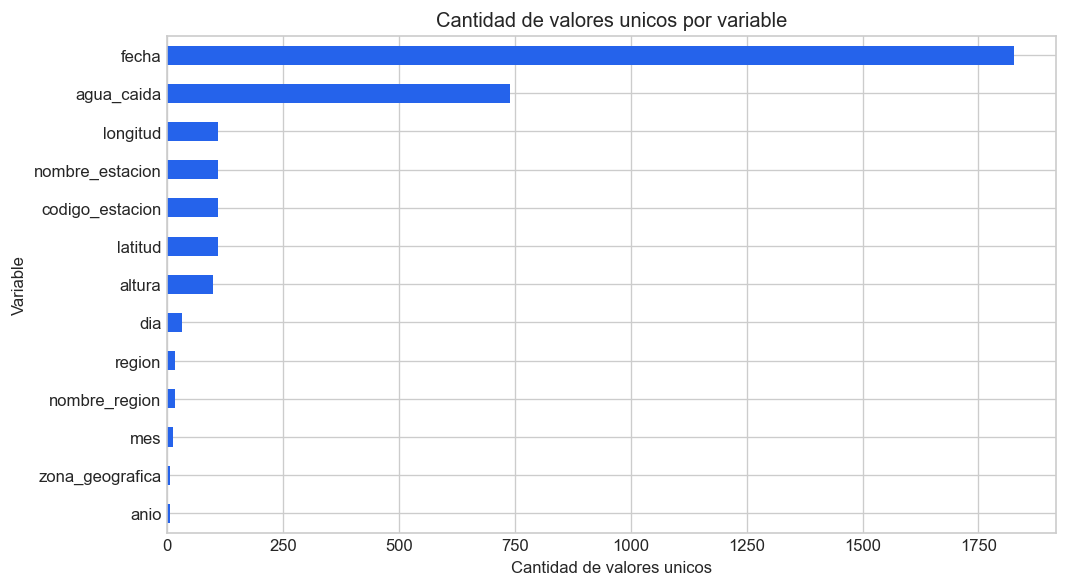

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
resumen_base["valores_unicos"].sort_values().plot(kind="barh", ax=ax, color="#2563eb")
ax.set_title("Cantidad de valores unicos por variable")
ax.set_xlabel("Cantidad de valores unicos")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()


In [4]:
clasificacion_variables = pd.DataFrame(
    {
        "variable": [
            "codigo_estacion", "nombre_estacion", "region", "nombre_region", "zona_geografica",
            "altura", "latitud", "longitud", "anio", "mes", "dia", "fecha", "agua_caida"
        ],
        "tipo_analitico": [
            "Categorica nominal codificada", "Categorica nominal", "Categorica nominal codificada",
            "Categorica nominal", "Categorica nominal", "Numerica discreta", "Numerica continua",
            "Numerica continua", "Numerica discreta temporal", "Numerica discreta temporal",
            "Numerica discreta temporal", "Temporal", "Numerica continua"
        ],
        "rol_en_el_proyecto": [
            "Identificador tecnico de estacion", "Identificador descriptivo de estacion",
            "Codigo territorial", "Referencia territorial descriptiva", "Contexto geografico agregado",
            "Predictor geografico", "Predictor geografico", "Predictor geografico",
            "Predictor temporal", "Predictor temporal", "Predictor temporal",
            "Secuencia cronologica", "Variable objetivo"
        ],
    }
)

display(clasificacion_variables)


,variable,tipo_analitico,rol_en_el_proyecto
0,codigo_estacion,Categorica nominal codificada,Identificador tecnico de estacion
1,nombre_estacion,Categorica nominal,Identificador descriptivo de estacion
2,region,Categorica nominal codificada,Codigo territorial
3,nombre_region,Categorica nominal,Referencia territorial descriptiva
4,zona_geografica,Categorica nominal,Contexto geografico agregado
5,altura,Numerica discreta,Predictor geografico
6,latitud,Numerica continua,Predictor geografico
7,longitud,Numerica continua,Predictor geografico
8,anio,Numerica discreta temporal,Predictor temporal
9,mes,Numerica discreta temporal,Predictor temporal


**Analisis.** El dataset enriquecido queda compuesto por 13 variables: tres categoricas textuales, dos codigos numericos de naturaleza nominal, seis variables numericas de apoyo analitico, una variable temporal completa (`fecha`) y la variable objetivo `agua_caida`. Un punto metodologico importante es que `codigo_estacion` y `region` no deben interpretarse como magnitudes continuas, ya que sus valores expresan etiquetas y no distancias reales entre categorias. La incorporacion de `nombre_estacion`, `nombre_region` y `zona_geografica` mejora ademas la interpretacion del caso desde una perspectiva territorial.


### 2.2 Identificar Nulos


Tal como se enfatiza en el material de apoyo, la revision de valores faltantes debe realizarse antes de cualquier transformacion relevante. En esta etapa no solo interesa cuantificar si existen nulos, sino tambien identificar en que variable se concentran y si su distribucion sugiere un comportamiento aleatorio o un patron sistematico.


In [5]:
tabla_nulos = pd.DataFrame(
    {
        "nulos": df.isnull().sum(),
        "porcentaje_nulos": (df.isnull().mean() * 100).round(2),
    }
).sort_values(["nulos", "porcentaje_nulos"], ascending=False)

nulos_region = (
    df.groupby("nombre_region")["agua_caida"]
      .agg(total="size", nulos=lambda s: s.isna().sum(), porcentaje_nulos=lambda s: round(s.isna().mean() * 100, 2))
      .sort_values("porcentaje_nulos", ascending=False)
)

nulos_anio = (
    df.groupby("anio")["agua_caida"]
      .agg(total="size", nulos=lambda s: s.isna().sum(), porcentaje_nulos=lambda s: round(s.isna().mean() * 100, 2))
      .sort_index()
)

display(tabla_nulos)
display(nulos_region.head(10))
display(nulos_anio)


,nulos,porcentaje_nulos
agua_caida,17063,9.08
codigo_estacion,0,0.00
region,0,0.00
altura,0,0.00
latitud,0,0.00
longitud,0,0.00
anio,0,0.00
mes,0,0.00
dia,0,0.00
fecha,0,0.00


,total,nulos,porcentaje_nulos
nombre_region,,,
AysÃ©n del Gral. Carlos IbÃ¡Ã±ez del Campo,10437,1946,18.65
De Los RÃ­os,6569,1156,17.60
TarapacÃ¡,4748,767,16.15
De Los Lagos,16434,2363,14.38
De La AraucanÃ­a,10956,1488,13.58
Coquimbo,15290,1655,10.82
Atacama,6120,614,10.03
Del Libertador Gral. Bernardo O'Higgins,9092,885,9.73
Del BiobÃ­o,8764,851,9.71


,total,nulos,porcentaje_nulos
anio,,,
2021,35606,4215,11.84
2022,35735,3412,9.55
2023,38325,4799,12.52
2024,39162,2954,7.54
2025,39048,1683,4.31


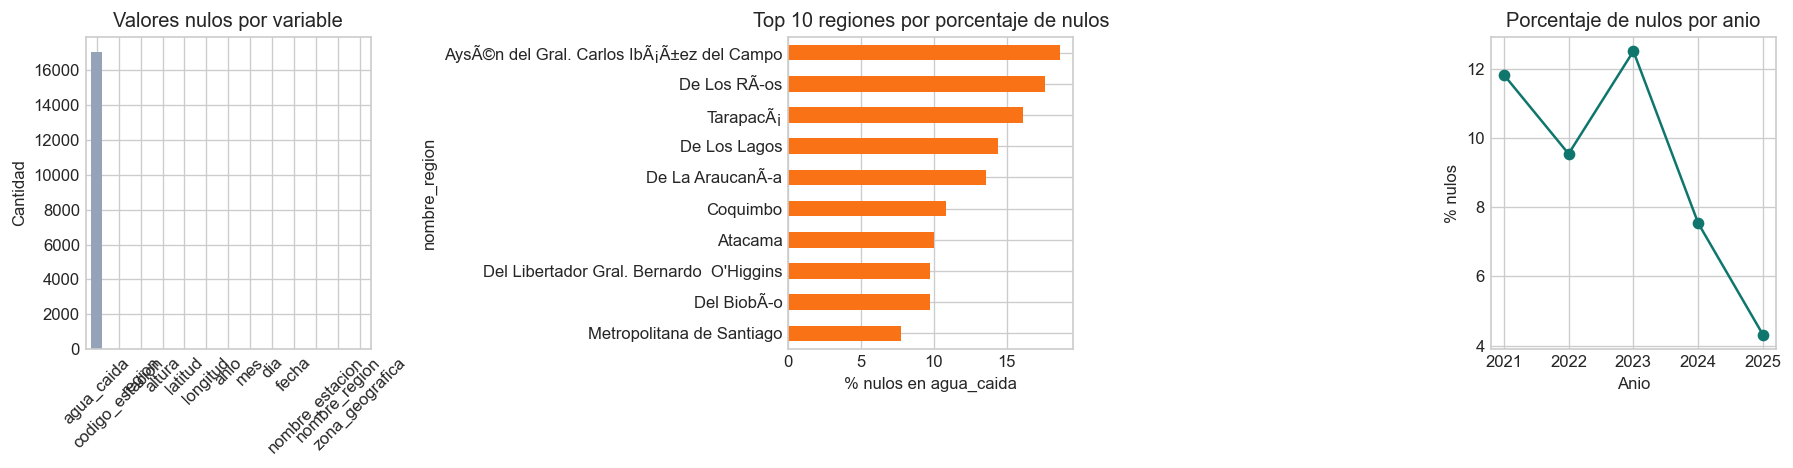

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

tabla_nulos["nulos"].plot(kind="bar", ax=axes[0], color="#94a3b8")
axes[0].set_title("Valores nulos por variable")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis="x", rotation=45)

nulos_region.head(10)["porcentaje_nulos"].sort_values().plot(kind="barh", ax=axes[1], color="#f97316")
axes[1].set_title("Top 10 regiones por porcentaje de nulos")
axes[1].set_xlabel("% nulos en agua_caida")

nulos_anio["porcentaje_nulos"].plot(marker="o", ax=axes[2], color="#0f766e")
axes[2].set_title("Porcentaje de nulos por anio")
axes[2].set_xlabel("Anio")
axes[2].set_ylabel("% nulos")

plt.tight_layout()
plt.show()


**Analisis.** El diagnostico muestra que los valores faltantes se concentran exclusivamente en `agua_caida`, con 17,063 registros nulos equivalentes al 9.08% del total. Esto significa que la calidad de los predictores es alta, pero la variable objetivo no esta completamente disponible. Ademas, la ausencia de datos no parece completamente aleatoria: regiones como Aysen del Gral. Carlos Ibanez del Campo (18.65%), De Los Rios (17.60%) y Tarapaca (16.15%) presentan porcentajes mas altos, y por anio los mayores niveles se observan en 2023 (12.52%) y 2021 (11.84%). En consecuencia, la estrategia de limpieza no debe asumir automaticamente que los nulos son irrelevantes, sino tratarlos con cuidado en funcion del objetivo del analisis.


### 2.3 Identificar Outliers


La deteccion de outliers debe realizarse con criterio estadistico y tambien con criterio de dominio. En precipitaciones diarias es esperable encontrar una distribucion muy asimetrica, con gran cantidad de ceros y pocos eventos intensos. Por ello, ademas del criterio IQR, conviene revisar percentiles altos y observar explicitamente los registros extremos antes de decidir si deben corregirse, conservarse o marcarse para revision.


In [7]:
distribucion_lluvia = pd.DataFrame(
    {
        "indicador": ["Dias sin precipitacion", "Dias con precipitacion", "Registros nulos"],
        "porcentaje": [
            round((df["agua_caida"] == 0).mean() * 100, 2),
            round((df["agua_caida"] > 0).mean() * 100, 2),
            round(df["agua_caida"].isna().mean() * 100, 2),
        ],
    }
)

q1 = df["agua_caida"].quantile(0.25)
q3 = df["agua_caida"].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
p95 = df["agua_caida"].quantile(0.95)
p99 = df["agua_caida"].quantile(0.99)

resumen_outliers = pd.DataFrame(
    {
        "Q1": [round(q1, 2)],
        "Q3": [round(q3, 2)],
        "IQR": [round(iqr, 2)],
        "Limite_superior_IQR": [round(upper, 2)],
        "Percentil_95": [round(p95, 2)],
        "Percentil_99": [round(p99, 2)],
        "Registros_sobre_IQR": [int((df["agua_caida"] > upper).sum())],
        "Registros_sobre_P99": [int((df["agua_caida"] >= p99).sum())],
        "Registros_mayores_100mm": [int((df["agua_caida"] > 100).sum())],
        "Registros_mayores_500mm": [int((df["agua_caida"] > 500).sum())],
    }
)

display(distribucion_lluvia)
display(resumen_outliers)


,indicador,porcentaje
0,Dias sin precipitacion,67.68
1,Dias con precipitacion,23.24
2,Registros nulos,9.08


,Q1,Q3,IQR,Limite_superior_IQR,Percentil_95,Percentil_99,Registros_sobre_IQR,Registros_sobre_P99,Registros_mayores_100mm,Registros_mayores_500mm
0,0.0,0.1,0.1,0.25,8.6,27.8,32994,1726,21,5


In [8]:
extremos_lluvia = (
    df.loc[df["agua_caida"].notna(), ["fecha", "nombre_estacion", "nombre_region", "agua_caida"]]
      .sort_values("agua_caida", ascending=False)
      .head(15)
)

display(extremos_lluvia)


,fecha,nombre_estacion,nombre_region,agua_caida
75680,2025-12-08,RÃ­o Clarillo,Metropolitana de Santiago,3574.300049
133239,2025-12-07,Isla Mocha Ad.,Del BiobÃ­o,3541.500000
75679,2025-12-07,RÃ­o Clarillo,Metropolitana de Santiago,2917.399902
133240,2025-12-09,Isla Mocha Ad.,Del BiobÃ­o,1459.900024
75681,2025-12-09,RÃ­o Clarillo,Metropolitana de Santiago,880.099976
97400,2023-08-21,"General Freire, CuricÃ³ Ad.",Del Maule,150.199997
74780,2023-06-22,RÃ­o Clarillo,Metropolitana de Santiago,145.199997
123155,2022-04-28,Lonquimay,De La AraucanÃ­a,136.399994
138886,2021-05-31,Corral ESSAL,De Los RÃ­os,126.800003
102878,2023-08-21,Nilahue - La Quebrada,Del Libertador Gral. Bernardo O'Higgins,121.300003


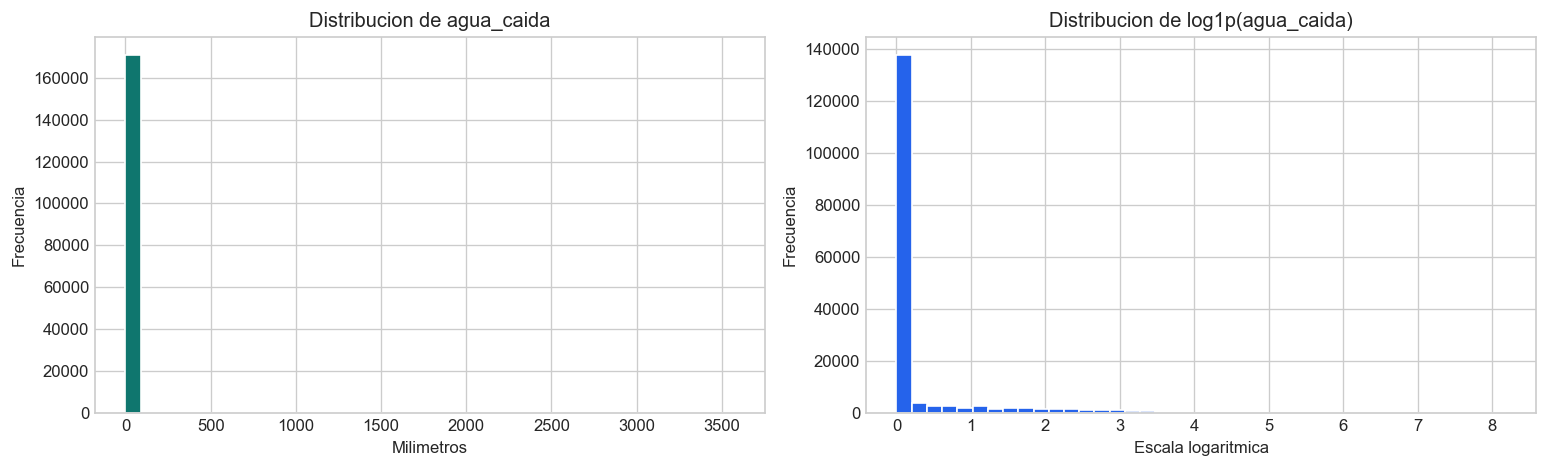

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["agua_caida"].dropna(), bins=40, color="#0f766e", edgecolor="white")
axes[0].set_title("Distribucion de agua_caida")
axes[0].set_xlabel("Milimetros")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(np.log1p(df["agua_caida"].dropna()), bins=40, color="#2563eb", edgecolor="white")
axes[1].set_title("Distribucion de log1p(agua_caida)")
axes[1].set_xlabel("Escala logaritmica")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


C:\Users\Amnesia\AppData\Local\Temp\ipykernel_25388\1055304736.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_box, labels=regiones_box, vert=False)
C:\Users\Amnesia\AppData\Local\Temp\ipykernel_25388\1055304736.py:15: UserWarning: Glyph 145 (\x91) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Amnesia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 145 (\x91) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


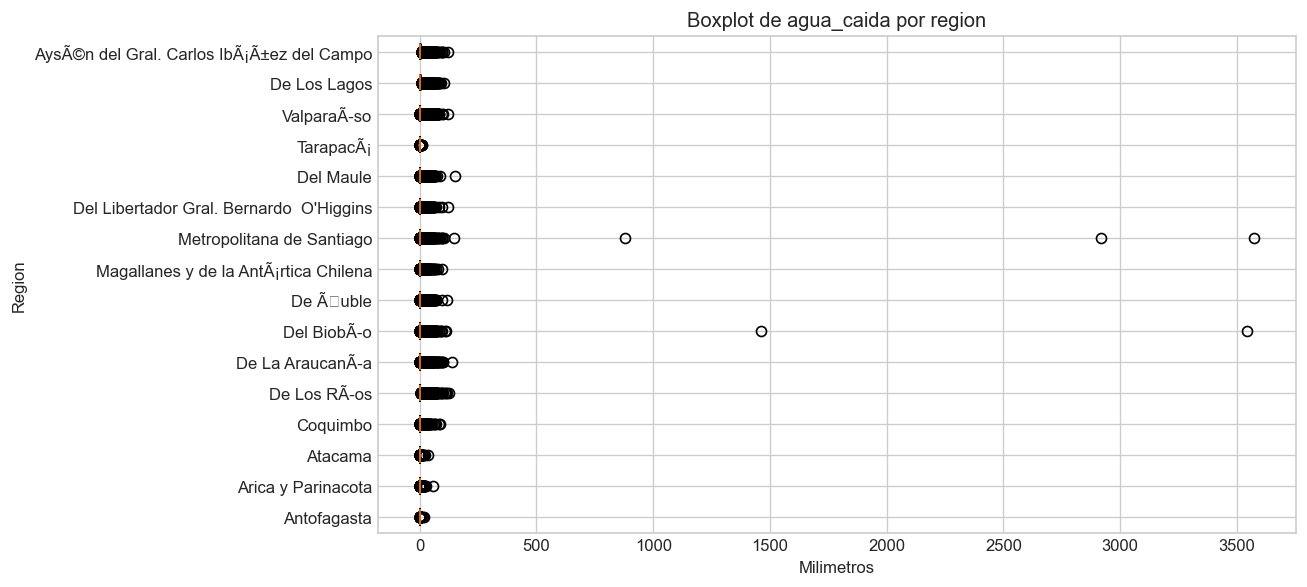

In [10]:
regiones_box = (
    df.groupby("nombre_region")["agua_caida"]
      .median()
      .sort_values()
      .index
      .tolist()
)
datos_box = [df.loc[df["nombre_region"] == region, "agua_caida"].dropna() for region in regiones_box]

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(datos_box, labels=regiones_box, vert=False)
ax.set_title("Boxplot de agua_caida por region")
ax.set_xlabel("Milimetros")
ax.set_ylabel("Region")
plt.tight_layout()
plt.show()


**Analisis.** La variable `agua_caida` presenta una distribucion fuertemente sesgada hacia cero. El criterio IQR entrega `Q1 = 0.00`, `Q3 = 0.10` y un limite superior de apenas 0.25 mm, por lo que 32,994 registros (17.56%) quedan por encima de ese umbral. En este caso, interpretar todos esos valores como outliers seria incorrecto, ya que el problema no radica en la presencia de errores evidentes sino en la estructura zero-inflated de la variable. Por ello, resulta mas razonable complementar la deteccion con percentiles altos: el percentil 99 se ubica en 27.8 mm, mientras que solo 21 registros superan los 100 mm y 5 registros superan los 500 mm. Estos valores extremos deben marcarse para revision, pero no eliminarse automaticamente, ya que pueden corresponder a eventos reales o a observaciones que requieren validacion adicional.


### 2.4 Transformaciones


Sobre la base del diagnostico anterior, se define un conjunto de trabajo orientado al analisis. Esta etapa no busca todavia optimizar un modelo, sino dejar la informacion en una forma mas interpretable y util para las fases posteriores, manteniendo tanto la trazabilidad territorial como la secuencia temporal de los registros.


In [11]:
columnas_trabajo = [
    "codigo_estacion", "nombre_estacion", "region", "nombre_region", "zona_geografica",
    "altura", "latitud", "longitud", "anio", "mes", "dia", "fecha", "agua_caida"
]

df_trabajo = df[columnas_trabajo].copy()

print("Columnas seleccionadas para el trabajo analitico:")
display(pd.DataFrame({"columnas": df_trabajo.columns}))
display(df_trabajo.head())


Columnas seleccionadas para el trabajo analitico:


,columnas
0,codigo_estacion
1,nombre_estacion
2,region
3,nombre_region
4,zona_geografica
5,altura
6,latitud
7,longitud
8,anio
9,mes


,codigo_estacion,nombre_estacion,region,nombre_region,zona_geografica,altura,latitud,longitud,anio,mes,dia,fecha,agua_caida
0,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,4084,-17.595,-69.4775,2023,1,1,2023-01-01,NaN
1,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,4084,-17.595,-69.4775,2023,1,2,2023-01-02,NaN
2,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,4084,-17.595,-69.4775,2023,1,3,2023-01-03,NaN
3,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,4084,-17.595,-69.4775,2023,1,4,2023-01-04,NaN
4,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,4084,-17.595,-69.4775,2023,1,5,2023-01-05,NaN


**Analisis.** El conjunto de trabajo conserva tanto los identificadores tecnicos como sus equivalentes descriptivos, ya que en esta fase interesa combinar trazabilidad con interpretabilidad. A diferencia de una base puramente orientada a modelamiento, aqui resulta util mantener `codigo_estacion` junto con `nombre_estacion`, asi como `region` junto con `nombre_region`, porque ambos pares facilitan la lectura del analisis y la deteccion de patrones territoriales. Asimismo, se preserva `fecha` como variable temporal completa para posteriores derivaciones cronologicas.


#### 2.4.1 A numericos (Encoder)


Las variables categoricas nominales deben transformarse a una representacion numerica cuando se desea utilizarlas en procedimientos cuantitativos. Siguiendo el material de apoyo, la estrategia mas consistente en este caso es `one-hot encoding`, ya que no existe un orden natural entre las categorias territoriales. Sin embargo, conviene aplicar esta transformacion con criterio, porque atributos de muy alta cardinalidad, como la estacion, pueden multiplicar innecesariamente el numero de columnas.


In [12]:
df_encoder = pd.get_dummies(
    df_trabajo[["nombre_region", "zona_geografica"]],
    columns=["nombre_region", "zona_geografica"],
    drop_first=False,
    dtype=int,
)

print(f"Shape original de columnas categoricas seleccionadas: {df_trabajo[['nombre_region', 'zona_geografica']].shape}")
print(f"Shape despues del encoding: {df_encoder.shape}")
display(df_encoder.head())


Shape original de columnas categoricas seleccionadas: (187876, 2)
Shape despues del encoding: (187876, 22)


,nombre_region_Antofagasta,nombre_region_Arica y Parinacota,nombre_region_Atacama,nombre_region_AysÃ©n del Gral. Carlos IbÃ¡Ã±ez del Campo,nombre_region_Coquimbo,nombre_region_De La AraucanÃ­a,nombre_region_De Los Lagos,nombre_region_De Los RÃ­os,nombre_region_De Ãuble,nombre_region_Del BiobÃ­o,nombre_region_Del Libertador Gral. Bernardo O'Higgins,nombre_region_Del Maule,nombre_region_Magallanes y de la AntÃ¡rtica Chilena,nombre_region_Metropolitana de Santiago,nombre_region_TarapacÃ¡,nombre_region_ValparaÃ­so,zona_geografica_Cordillera,zona_geografica_Litoral,zona_geografica_PreCordillera,zona_geografica_Secano Costero,zona_geografica_Secano Interior,zona_geografica_Valle
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


**Analisis.** Se utiliza `one-hot encoding` porque `nombre_region` y `zona_geografica` son categorias nominales sin jerarquia intrinseca. Esta decision evita imponer relaciones artificiales entre regiones o zonas. En esta fase no se codifica la estacion de manera exhaustiva, ya que su alta cardinalidad incrementaria considerablemente el numero de columnas y dificultaria la interpretacion inicial. Por lo tanto, se privilegia una codificacion territorial mas compacta y mas alineada con el objetivo de entendimiento de datos.


#### 2.4.2 Tratamiento de Nulos


Dado que los nulos se concentran en la variable objetivo, su tratamiento requiere una decision distinta a la de un predictor comun. Imputar directamente `agua_caida` podria introducir sesgos importantes en un problema donde la ausencia o presencia de lluvia es precisamente el fenomeno de interes. Por ello, en esta etapa se construye un dataset analitico limpio excluyendo unicamente los registros sin valor objetivo observado.


In [13]:
filas_antes = len(df_trabajo)
df_modelo = df_trabajo.dropna(subset=["agua_caida"]).copy()
filas_despues = len(df_modelo)
filas_eliminadas = filas_antes - filas_despues
nulos_predictores = df_modelo.drop(columns=["agua_caida"]).isnull().sum().sum()

resumen_limpieza_nulos = pd.DataFrame(
    {
        "filas_antes": [filas_antes],
        "filas_despues": [filas_despues],
        "filas_eliminadas": [filas_eliminadas],
        "porcentaje_eliminado": [round(filas_eliminadas / filas_antes * 100, 2)],
        "nulos_en_predictores": [int(nulos_predictores)],
    }
)

display(resumen_limpieza_nulos)
display(df_modelo.head())


,filas_antes,filas_despues,filas_eliminadas,porcentaje_eliminado,nulos_en_predictores
0,187876,170813,17063,9.08,0


,codigo_estacion,nombre_estacion,region,nombre_region,zona_geografica,altura,latitud,longitud,anio,mes,dia,fecha,agua_caida
273,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,4084,-17.595,-69.4775,2023,10,1,2023-10-01,0.0
274,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,4084,-17.595,-69.4775,2023,10,2,2023-10-02,0.0
275,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,4084,-17.595,-69.4775,2023,10,3,2023-10-03,0.0
276,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,4084,-17.595,-69.4775,2023,10,4,2023-10-04,0.0
277,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,4084,-17.595,-69.4775,2023,10,5,2023-10-05,0.0


**Analisis.** La limpieza elimina 17,063 registros sin valor en `agua_caida`, dejando un conjunto analitico de 170,813 filas. La decision es metodologicamente defendible porque el valor faltante se ubica en la variable objetivo y su imputacion podria distorsionar la relacion real entre lluvia, tiempo y territorio. Ademas, una vez realizada esta depuracion, los predictores permanecen completos, lo que permite continuar el analisis sin introducir imputaciones artificiales en esta etapa.


#### 2.4.3 Tratamiento de Outliers


En un problema climaticamente variable, eliminar outliers de manera automatica puede implicar la perdida de eventos relevantes. En consecuencia, se adopta una estrategia conservadora: mantener los registros, crear una transformacion logaritmica que reduzca la asimetria y agregar una marca para identificar eventos extremos definidos a partir del percentil 99.


In [14]:
umbral_extremo_p99 = df_modelo["agua_caida"].quantile(0.99)

df_modelo["agua_caida_log"] = np.log1p(df_modelo["agua_caida"])
df_modelo["evento_extremo_p99"] = (df_modelo["agua_caida"] >= umbral_extremo_p99).astype(int)
df_modelo["revision_manual_mayor_100"] = (df_modelo["agua_caida"] > 100).astype(int)

comparacion_escala = df_modelo[["agua_caida", "agua_caida_log"]].describe().T.round(2)
resumen_extremos = pd.DataFrame(
    {
        "umbral_p99": [round(umbral_extremo_p99, 2)],
        "eventos_extremos_p99": [int(df_modelo["evento_extremo_p99"].sum())],
        "registros_mayores_100mm": [int(df_modelo["revision_manual_mayor_100"].sum())],
        "registros_mayores_500mm": [int((df_modelo["agua_caida"] > 500).sum())],
    }
)

display(comparacion_escala)
display(resumen_extremos)


,count,mean,std,min,25%,50%,75%,max
agua_caida,170813.0,1.49,15.67,0.0,0.0,0.0,0.1,3574.30
agua_caida_log,170813.0,0.31,0.76,0.0,0.0,0.0,0.1,8.18


,umbral_p99,eventos_extremos_p99,registros_mayores_100mm,registros_mayores_500mm
0,27.8,1726,21,5


**Analisis.** La estrategia seleccionada no elimina precipitaciones extremas, sino que conserva los registros y los hace mas manejables desde el punto de vista analitico. La transformacion `log1p` reduce la dispersion de la variable y facilita posteriores comparaciones, mientras que `evento_extremo_p99` identifica 1,726 observaciones por sobre 27.8 mm. Este enfoque es mas consistente con la naturaleza del problema, ya que los eventos poco frecuentes forman parte del fenomeno estudiado y, por lo mismo, deben ser preservados y analizados con criterio en lugar de descartarse automaticamente.


### 2.5 Analisis estadisticos basicos


Una vez revisada la calidad general del dataset, corresponde resumir sus principales estadisticas descriptivas. En esta subseccion se examinan tanto las variables numericas base como la forma en que la precipitacion cambia entre regiones, con el fin de caracterizar el comportamiento general del conjunto antes de avanzar a correlaciones y construccion de nuevas variables.


In [15]:
estadisticas_numericas = (
    df_modelo[["altura", "latitud", "longitud", "anio", "mes", "dia", "agua_caida", "agua_caida_log"]]
    .describe()
    .T
    .round(2)
)

resumen_region = (
    df_modelo.groupby("nombre_region")["agua_caida"]
    .agg(
        media="mean",
        mediana="median",
        suma="sum",
        maximo="max",
        frecuencia_lluvia=lambda s: (s > 0).mean() * 100,
    )
    .round(2)
    .sort_values("media", ascending=False)
)

display(estadisticas_numericas)
display(resumen_region)


,count,mean,std,min,25%,50%,75%,max
altura,170813.0,426.52,722.15,5.00,53.00,152.00,460.00,4084.00
latitud,170813.0,-35.85,8.97,-62.19,-39.89,-33.71,-32.22,-17.60
longitud,170813.0,-71.70,4.36,-109.43,-72.28,-71.17,-70.68,-58.98
anio,170813.0,2023.09,1.42,2021.00,2022.00,2023.00,2024.00,2025.00
mes,170813.0,6.58,3.44,1.00,4.00,7.00,10.00,12.00
dia,170813.0,15.73,8.81,1.00,8.00,16.00,23.00,31.00
agua_caida,170813.0,1.49,15.67,0.00,0.00,0.00,0.10,3574.30
agua_caida_log,170813.0,0.31,0.76,0.00,0.00,0.00,0.10,8.18


,media,mediana,suma,maximo,frecuencia_lluvia
nombre_region,,,,,
De Los RÃ­os,4.23,0.0,22889.6,126.8,49.82
AysÃ©n del Gral. Carlos IbÃ¡Ã±ez del Campo,3.89,0.2,33021.5,120.0,53.55
De Los Lagos,3.69,0.2,51869.2,103.4,55.97
Del BiobÃ­o,3.05,0.0,24151.9,3541.5,32.30
De La AraucanÃ­a,2.50,0.0,23623.4,136.4,40.67
De Ãuble,2.26,0.0,9493.6,115.6,30.33
Del Maule,1.55,0.0,8012.4,150.2,24.50
Magallanes y de la AntÃ¡rtica Chilena,1.22,0.0,23030.7,95.2,45.53
Metropolitana de Santiago,0.95,0.0,24464.0,3574.3,11.76


C:\Users\Amnesia\AppData\Local\Temp\ipykernel_25388\2851653114.py:13: UserWarning: Glyph 145 (\x91) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Amnesia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 145 (\x91) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


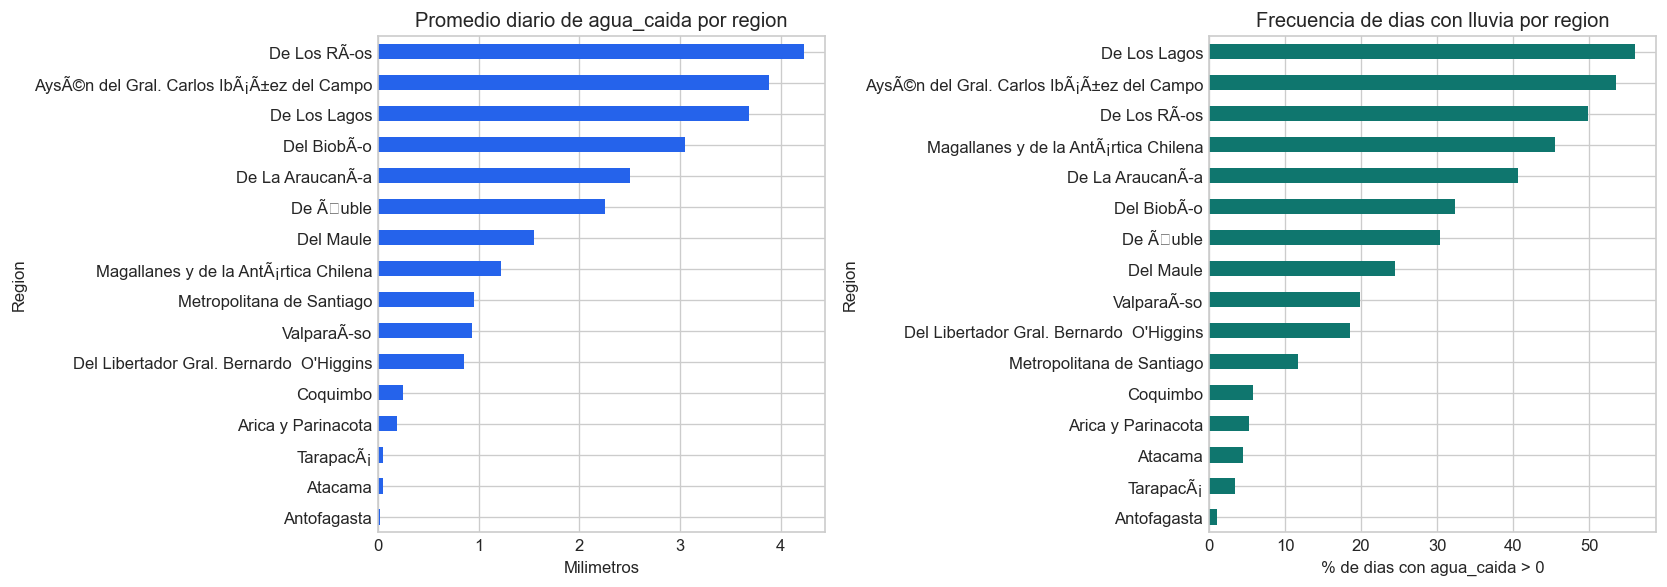

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

resumen_region["media"].sort_values().plot(kind="barh", ax=axes[0], color="#2563eb")
axes[0].set_title("Promedio diario de agua_caida por region")
axes[0].set_xlabel("Milimetros")
axes[0].set_ylabel("Region")

resumen_region["frecuencia_lluvia"].sort_values().plot(kind="barh", ax=axes[1], color="#0f766e")
axes[1].set_title("Frecuencia de dias con lluvia por region")
axes[1].set_xlabel("% de dias con agua_caida > 0")
axes[1].set_ylabel("Region")

plt.tight_layout()
plt.show()


**Analisis.** La estadistica descriptiva confirma que `agua_caida` posee una distribucion muy asimetrica: la media es 1.49 mm, la mediana es 0 mm y el maximo alcanza 3574.3 mm. A nivel regional, los mayores promedios diarios se observan en De Los Rios (4.23 mm), Aysen del Gral. Carlos Ibanez del Campo (3.89 mm) y De Los Lagos (3.69 mm), mientras que las frecuencias mas altas de dias con lluvia dentro del conjunto limpio corresponden a De Los Lagos (55.97%), Aysen del Gral. Carlos Ibanez del Campo (53.55%) y De Los Rios (49.82%). En contraste, el norte presenta niveles medios muy bajos y menor frecuencia de precipitacion, lo que evidencia una heterogeneidad territorial marcada.


### 2.6 Matriz de Correlacion


La correlacion inicial se calcula solo sobre variables numericas en bruto y utilizando el coeficiente de Pearson, tal como se revisa en el material de apoyo. Esta medida resulta util como primera aproximacion lineal, aunque debe interpretarse con cautela debido a la fuerte asimetria de `agua_caida` y a la presencia de relaciones que pueden no ser estrictamente lineales.


In [17]:
corr_inicial = (
    df_modelo[["altura", "latitud", "longitud", "anio", "mes", "dia", "agua_caida"]]
    .corr(numeric_only=True)
    .round(3)
)

display(corr_inicial)
display(corr_inicial["agua_caida"].sort_values(ascending=False))


,altura,latitud,longitud,anio,mes,dia,agua_caida
altura,1.000,0.382,0.172,0.043,0.007,-0.001,-0.026
latitud,0.382,1.000,-0.083,0.003,0.000,-0.001,-0.044
longitud,0.172,-0.083,1.000,0.004,-0.000,-0.000,-0.025
anio,0.043,0.003,0.004,1.000,0.005,0.002,0.013
mes,0.007,0.000,-0.000,0.005,1.000,0.010,0.009
dia,-0.001,-0.001,-0.000,0.002,0.010,1.000,-0.004
agua_caida,-0.026,-0.044,-0.025,0.013,0.009,-0.004,1.000


agua_caida    1.000
anio          0.013
mes           0.009
dia          -0.004
longitud     -0.025
altura       -0.026
latitud      -0.044
Name: agua_caida, dtype: float64

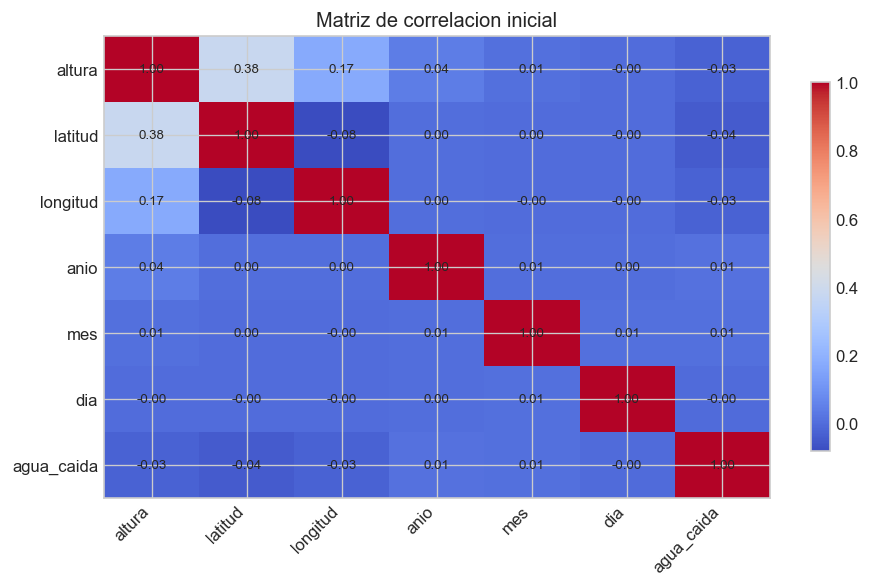

In [18]:
heatmap_df(corr_inicial, "Matriz de correlacion inicial", cmap="coolwarm", figsize=(8, 5), decimals=2)


**Analisis.** La matriz de correlacion inicial muestra relaciones lineales muy debiles entre `agua_caida` y las variables numericas disponibles en su forma bruta. La asociacion de mayor magnitud absoluta corresponde a `latitud` (-0.044), seguida por `altura` (-0.026) y `longitud` (-0.025), mientras que `anio`, `mes` y `dia` presentan coeficientes cercanos a cero. Esto sugiere que, a nivel diario, la precipitacion no queda bien representada por relaciones lineales simples y que sera necesario construir variables mas expresivas para capturar su comportamiento temporal y territorial.


### 2.7 Patrones/comportamientos detectados


Mas alla de la correlacion lineal, el entendimiento de los datos exige observar patrones concretos en el tiempo y en el espacio. En esta subseccion se resume la precipitacion por mes, por anio y por region, con el proposito de identificar comportamientos recurrentes, periodos de mayor intensidad y diferencias sistematicas entre zonas del pais.


In [19]:
lluvia_mensual = (
    df_modelo.groupby("mes")["agua_caida"]
    .agg(media="mean", suma="sum", maximo="max")
    .round(2)
)

lluvia_anual = (
    df_modelo.groupby("anio")["agua_caida"]
    .agg(media="mean", suma="sum", maximo="max")
    .round(2)
)

frecuencia_region = (
    df_modelo.assign(tiene_lluvia=df_modelo["agua_caida"] > 0)
    .groupby("nombre_region")["tiene_lluvia"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

top_estaciones = (
    df_modelo.groupby("nombre_estacion")
    .agg(
        media_lluvia=("agua_caida", "mean"),
        frecuencia_lluvia=("agua_caida", lambda s: (s > 0).mean() * 100),
        region=("nombre_region", "first"),
    )
    .sort_values("frecuencia_lluvia", ascending=False)
    .round(2)
)

display(lluvia_mensual)
display(lluvia_anual)
display(frecuencia_region.head(10))
display(top_estaciones.head(10))


,media,suma,maximo
mes,,,
1,0.61,8554.7,72.6
2,0.57,7165.9,66.0
3,0.98,14091.4,80.4
4,1.47,20775.9,136.4
5,1.84,27008.6,126.8
6,3.01,41751.4,145.2
7,2.11,30073.9,114.3
8,2.32,34107.5,150.2
9,1.79,25489.9,117.2


,media,suma,maximo
anio,,,
2021,1.13,35391.7,126.8
2022,1.39,44968.2,136.4
2023,1.60,53502.0,150.2
2024,1.54,55703.3,98.6
2025,1.76,65703.7,3574.3


nombre_region
De Los Lagos                                  55.97
AysÃ©n del Gral. Carlos IbÃ¡Ã±ez del Campo    53.55
De Los RÃ­os                                  49.82
Magallanes y de la AntÃ¡rtica Chilena         45.53
De La AraucanÃ­a                              40.67
Del BiobÃ­o                                   32.30
De Ãuble                                     30.33
Del Maule                                     24.50
ValparaÃ­so                                   19.87
Del Libertador Gral. Bernardo  O'Higgins      18.52
Name: tiene_lluvia, dtype: float64

,media_lluvia,frecuencia_lluvia,region
nombre_estacion,,,
Cisnes Puyuhuapi,7.85,70.51,AysÃ©n del Gral. Carlos IbÃ¡Ã±ez del Campo
Nueva ChaitÃ©n,6.10,66.10,De Los Lagos
Melinka Ad.,5.88,66.08,AysÃ©n del Gral. Carlos IbÃ¡Ã±ez del Campo
Puerto Varas ESSAL,2.21,63.88,De Los Lagos
QuellÃ³n Ad.,3.88,63.81,De Los Lagos
Puerto AysÃ©n Ad.,5.29,63.60,AysÃ©n del Gral. Carlos IbÃ¡Ã±ez del Campo
Juan Kalt Bode (FundaciÃ³n Adolfo Matthei),3.35,60.12,De Los Lagos
"Escuela Mirasol, Puerto Montt",3.32,55.58,De Los Lagos
"Juan FernÃ¡ndez, EstaciÃ³n MeteorolÃ³gica.",2.57,55.15,ValparaÃ­so


In [20]:
patron_region_mes = (
    df_modelo.pivot_table(
        index="mes",
        columns="nombre_region",
        values="agua_caida",
        aggfunc="mean",
    )
    .round(2)
)

display(patron_region_mes)


nombre_region,Antofagasta,Arica y Parinacota,Atacama,AysÃ©n del Gral. Carlos IbÃ¡Ã±ez del Campo,Coquimbo,De La AraucanÃ­a,De Los Lagos,De Los RÃ­os,De Ãuble,Del BiobÃ­o,Del Libertador Gral. Bernardo O'Higgins,Del Maule,Magallanes y de la AntÃ¡rtica Chilena,Metropolitana de Santiago,TarapacÃ¡,ValparaÃ­so
mes,,,,,,,,,,,,,,,,
1,0.02,0.61,0.00,1.92,0.00,1.02,1.63,1.31,0.50,0.40,0.20,0.49,1.00,0.24,0.15,0.32
2,0.07,0.69,0.00,2.20,0.00,0.43,1.70,1.37,0.02,0.19,0.02,0.15,1.20,0.02,0.16,0.43
3,0.03,0.43,0.00,4.54,0.00,1.68,2.99,3.44,0.65,1.25,0.08,0.28,1.39,0.05,0.10,0.44
4,0.01,0.05,0.05,4.00,0.03,3.26,4.57,5.81,1.60,2.72,0.58,1.25,1.45,0.29,0.02,0.82
5,0.01,0.01,0.01,4.62,0.27,3.44,4.59,6.32,2.98,3.00,1.01,2.32,1.51,1.12,0.00,1.25
6,0.02,0.01,0.08,5.13,0.93,6.02,6.31,8.30,6.34,7.30,2.36,4.31,1.21,2.31,0.00,2.70
7,0.01,0.01,0.27,6.72,1.05,3.47,4.99,5.36,3.50,4.65,1.03,2.05,1.57,0.89,0.00,1.44
8,0.01,0.00,0.11,3.81,0.57,3.91,4.81,5.88,4.74,3.80,2.72,4.41,1.28,1.92,0.00,1.99
9,0.00,0.00,0.01,5.07,0.07,3.37,4.66,5.92,3.77,3.44,1.12,2.49,1.04,0.74,0.01,0.89


C:\Users\Amnesia\AppData\Local\Temp\ipykernel_25388\2331650516.py:18: UserWarning: Glyph 145 (\x91) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Amnesia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 145 (\x91) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


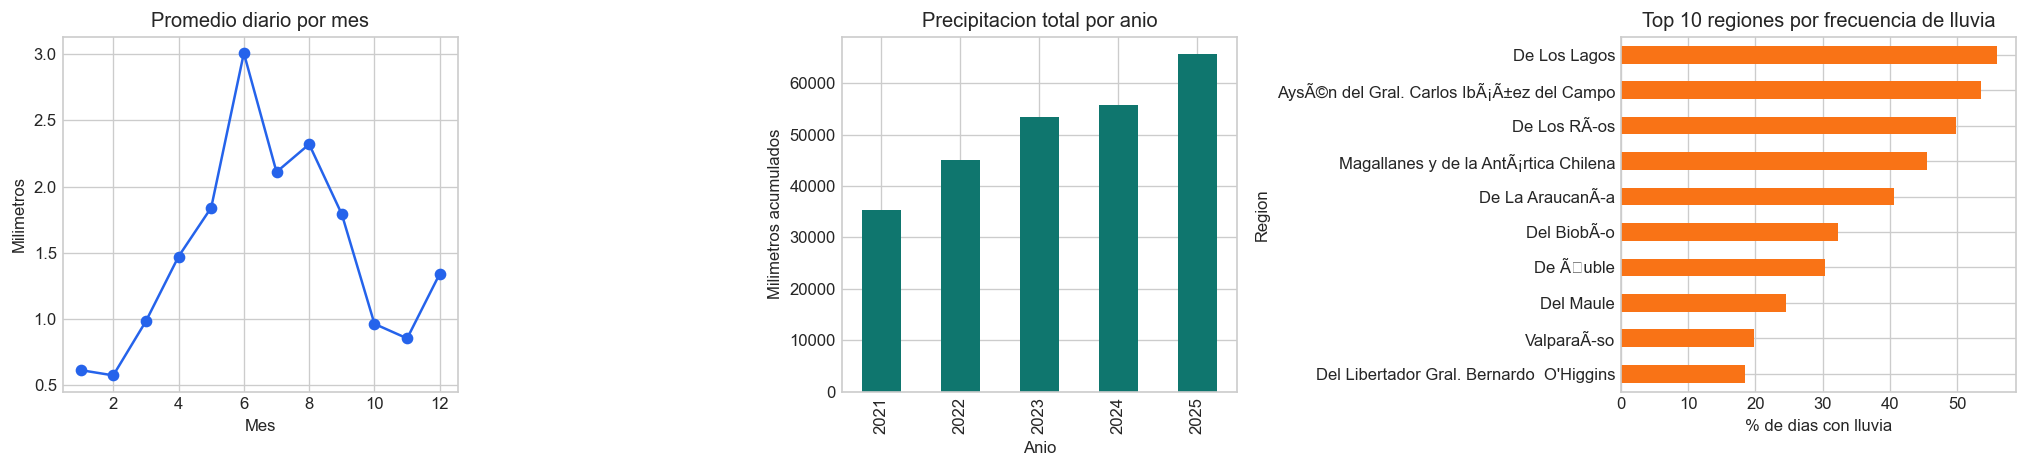

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

lluvia_mensual["media"].plot(marker="o", ax=axes[0], color="#2563eb")
axes[0].set_title("Promedio diario por mes")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Milimetros")

lluvia_anual["suma"].plot(kind="bar", ax=axes[1], color="#0f766e")
axes[1].set_title("Precipitacion total por anio")
axes[1].set_xlabel("Anio")
axes[1].set_ylabel("Milimetros acumulados")

frecuencia_region.head(10).sort_values().plot(kind="barh", ax=axes[2], color="#f97316")
axes[2].set_title("Top 10 regiones por frecuencia de lluvia")
axes[2].set_xlabel("% de dias con lluvia")
axes[2].set_ylabel("Region")

plt.tight_layout()
plt.show()


C:\Users\Amnesia\AppData\Local\Temp\ipykernel_25388\3113635144.py:31: UserWarning: Glyph 145 (\x91) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Amnesia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 145 (\x91) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


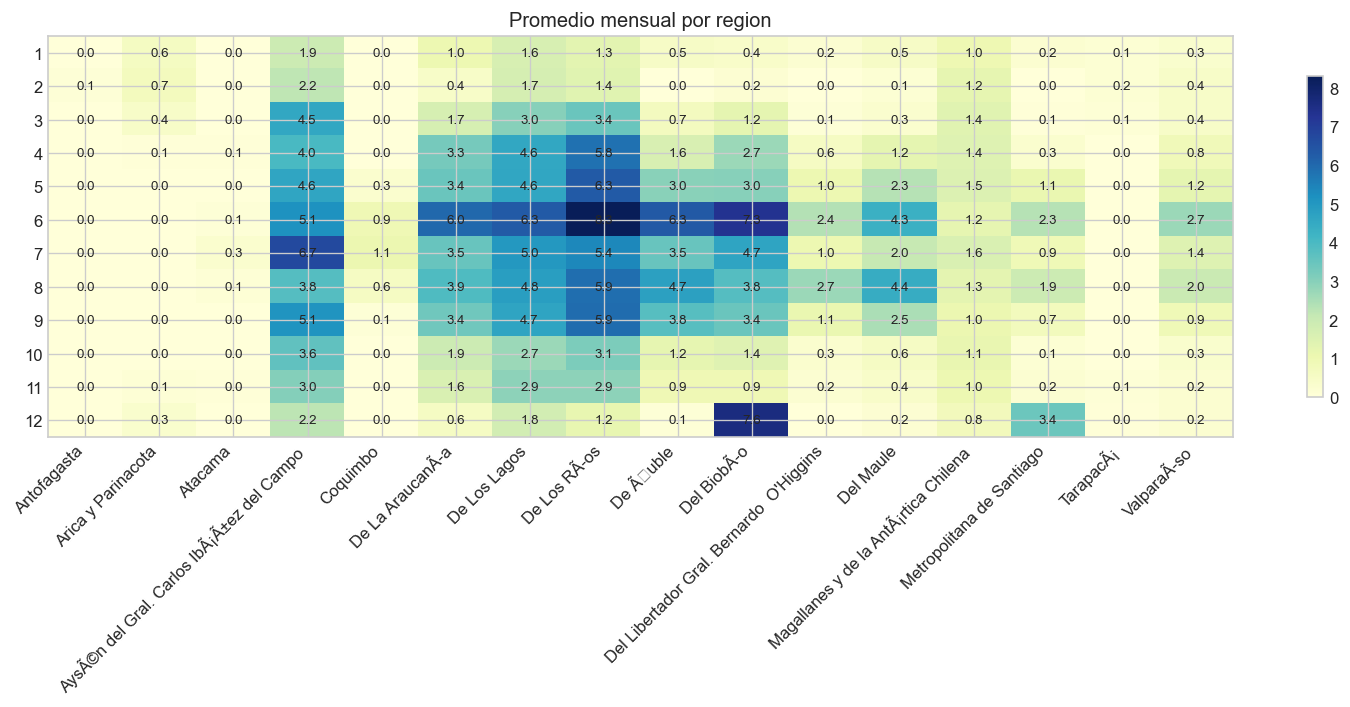

In [22]:
heatmap_df(patron_region_mes, "Promedio mensual por region", cmap="YlGnBu", figsize=(13, 6), decimals=1)


**Analisis.** A nivel agregado, los meses con mayor precipitacion media corresponden a junio (3.01 mm), agosto (2.32 mm) y julio (2.11 mm), mientras que enero y febrero presentan los niveles mas bajos. Por anio, la precipitacion total muestra un incremento desde 35,391.7 mm en 2021 hasta 65,703.7 mm en 2025, aunque este ultimo periodo incluye algunos eventos extremos que conviene revisar por separado. Territorialmente, el patron mensual evidencia una mayor concentracion de lluvias entre otono e invierno en el sur y la zona austral, mientras que el norte se mantiene seco la mayor parte del ano y solo presenta alzas menores en ciertos meses. En consecuencia, el comportamiento de la precipitacion combina una estacionalidad clara con diferencias espaciales muy marcadas.


### 2.8 Nuevas variables a partir del analisis


A partir de los patrones detectados, resulta conveniente construir variables que representen mejor la naturaleza ciclica del tiempo y la agrupacion territorial de las estaciones. La finalidad de estas nuevas variables no es aumentar artificialmente la dimensionalidad, sino incorporar estructuras que las columnas originales no capturan de forma directa.


In [23]:
estaciones = {
    12: "Verano", 1: "Verano", 2: "Verano",
    3: "Otono", 4: "Otono", 5: "Otono",
    6: "Invierno", 7: "Invierno", 8: "Invierno",
    9: "Primavera", 10: "Primavera", 11: "Primavera",
}

df_features = df_modelo.copy()
df_features["estacion_anual"] = df_features["mes"].map(estaciones)
df_features["dia_del_anio"] = df_features["fecha"].dt.dayofyear
df_features["mes_sin"] = np.sin(2 * np.pi * df_features["mes"] / 12)
df_features["mes_cos"] = np.cos(2 * np.pi * df_features["mes"] / 12)
df_features["dia_sin"] = np.sin(2 * np.pi * df_features["dia_del_anio"] / 365.25)
df_features["dia_cos"] = np.cos(2 * np.pi * df_features["dia_del_anio"] / 365.25)
df_features["lluvia_evento"] = (df_features["agua_caida"] > 0).astype(int)
df_features["macrozona"] = df_features["region"].apply(region_to_macrozone)

display(
    df_features[
        [
            "fecha", "mes", "dia_del_anio", "estacion_anual", "mes_sin", "mes_cos",
            "dia_sin", "dia_cos", "lluvia_evento", "macrozona"
        ]
    ].head(12)
)


,fecha,mes,dia_del_anio,estacion_anual,mes_sin,mes_cos,dia_sin,dia_cos,lluvia_evento,macrozona
273,2023-10-01,10,274,Primavera,-0.866025,0.5,-0.999999,0.001075,0,Norte
274,2023-10-02,10,275,Primavera,-0.866025,0.5,-0.999833,0.018277,0,Norte
275,2023-10-03,10,276,Primavera,-0.866025,0.5,-0.999371,0.035473,0,Norte
276,2023-10-04,10,277,Primavera,-0.866025,0.5,-0.998613,0.052658,0,Norte
277,2023-10-05,10,278,Primavera,-0.866025,0.5,-0.997559,0.069828,0,Norte
278,2023-10-06,10,279,Primavera,-0.866025,0.5,-0.996210,0.086977,0,Norte
279,2023-10-07,10,280,Primavera,-0.866025,0.5,-0.994567,0.104101,0,Norte
280,2023-10-08,10,281,Primavera,-0.866025,0.5,-0.992629,0.121193,0,Norte
281,2023-10-09,10,282,Primavera,-0.866025,0.5,-0.990397,0.138250,0,Norte
282,2023-10-10,10,283,Primavera,-0.866025,0.5,-0.987873,0.155266,0,Norte


**Analisis.** Las variables derivadas permiten representar de mejor manera la dinamica observada en la fase exploratoria. `estacion_anual` resume el calendario meteorologico, `dia_del_anio` y sus componentes ciclicas (`dia_sin`, `dia_cos`) evitan tratar la secuencia temporal como una escala lineal simple, `lluvia_evento` separa la ocurrencia de la intensidad y `macrozona` sintetiza diferencias territoriales de mayor escala. En conjunto, estas variables aportan una representacion mas cercana a la logica del fenomeno que las columnas crudas por si solas.


### 2.9 Matriz de Correlacion


Con las nuevas variables disponibles, se recalcula la matriz de correlacion utilizando `agua_caida_log` como referencia analitica. Esta decision permite reducir el efecto de la asimetria extrema de la variable objetivo y facilita una lectura mas interpretable de las asociaciones lineales entre la precipitacion y las variables derivadas.


In [24]:
corr_extendida = df_features[
    [
        "altura", "latitud", "longitud", "anio", "mes_sin", "mes_cos",
        "dia_sin", "dia_cos", "lluvia_evento", "agua_caida_log"
    ]
].copy()

for macrozona in ["Norte", "Centro", "Sur", "Austral"]:
    corr_extendida[f"macrozona_{macrozona.lower()}"] = (df_features["macrozona"] == macrozona).astype(int)

matriz_corr_extendida = corr_extendida.corr(numeric_only=True).round(3)

display(matriz_corr_extendida)
display(matriz_corr_extendida["agua_caida_log"].sort_values(ascending=False))


,altura,latitud,longitud,anio,mes_sin,mes_cos,dia_sin,dia_cos,lluvia_evento,agua_caida_log,macrozona_norte,macrozona_centro,macrozona_sur,macrozona_austral
altura,1.000,0.382,0.172,0.043,-0.003,0.004,-0.004,0.003,-0.154,-0.119,0.281,0.093,-0.212,-0.197
latitud,0.382,1.000,-0.083,0.003,0.003,0.001,0.003,0.001,-0.343,-0.239,0.651,0.209,-0.233,-0.751
longitud,0.172,-0.083,1.000,0.004,0.001,-0.001,0.001,-0.001,-0.131,-0.111,0.167,-0.116,-0.138,0.122
anio,0.043,0.003,0.004,1.000,-0.006,0.006,-0.008,0.004,0.021,0.019,-0.002,-0.013,0.015,0.002
mes_sin,-0.003,0.003,0.001,-0.006,1.000,-0.012,0.954,0.249,-0.062,-0.058,0.008,-0.000,-0.011,0.004
mes_cos,0.004,0.001,-0.001,0.006,-0.012,1.000,-0.270,0.953,-0.173,-0.147,0.002,-0.011,0.009,0.002
dia_sin,-0.004,0.003,0.001,-0.008,0.954,-0.270,1.000,-0.009,-0.014,-0.017,0.007,0.002,-0.012,0.004
dia_cos,0.003,0.001,-0.001,0.004,0.249,0.953,-0.009,1.000,-0.188,-0.161,0.004,-0.011,0.006,0.003
lluvia_evento,-0.154,-0.343,-0.131,0.021,-0.062,-0.173,-0.014,-0.188,1.000,0.706,-0.267,-0.154,0.244,0.225
agua_caida_log,-0.119,-0.239,-0.111,0.019,-0.058,-0.147,-0.017,-0.161,0.706,1.000,-0.200,-0.139,0.238,0.135


agua_caida_log       1.000
lluvia_evento        0.706
macrozona_sur        0.238
macrozona_austral    0.135
anio                 0.019
dia_sin             -0.017
mes_sin             -0.058
longitud            -0.111
altura              -0.119
macrozona_centro    -0.139
mes_cos             -0.147
dia_cos             -0.161
macrozona_norte     -0.200
latitud             -0.239
Name: agua_caida_log, dtype: float64

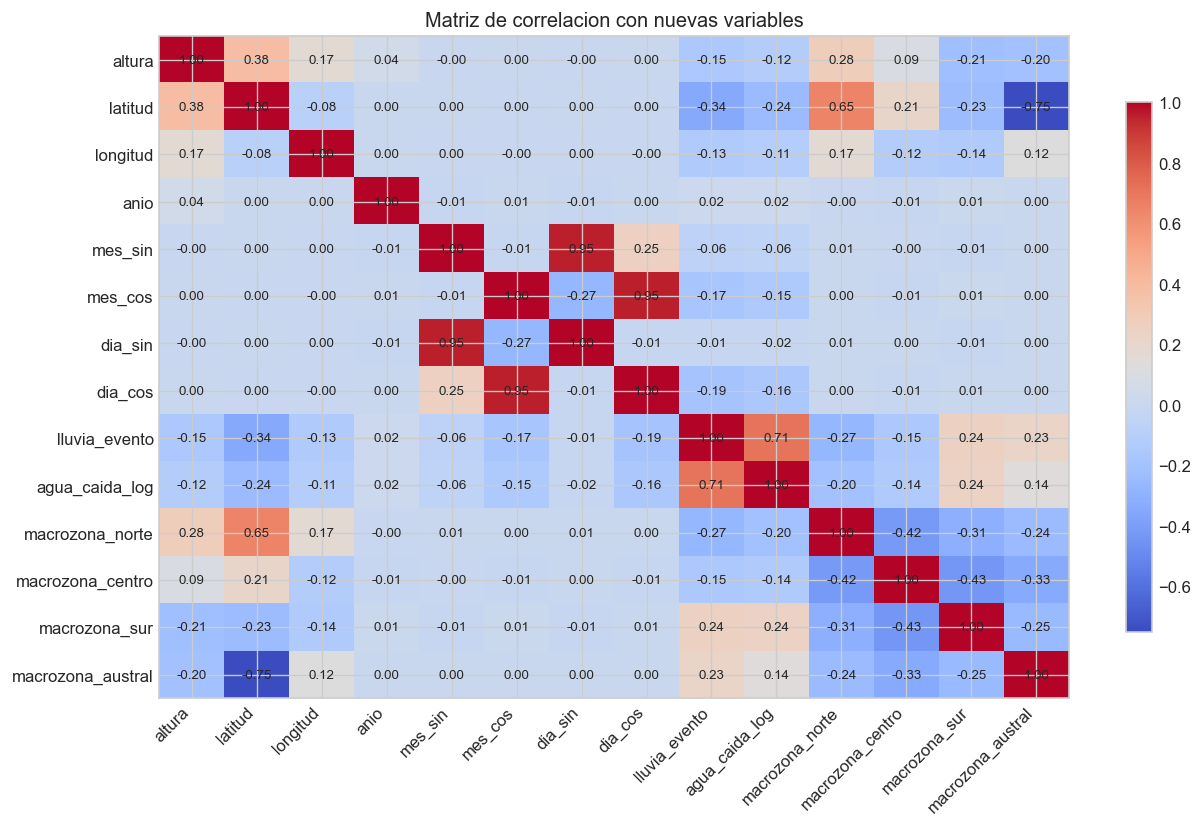

In [25]:
heatmap_df(
    matriz_corr_extendida,
    "Matriz de correlacion con nuevas variables",
    cmap="coolwarm",
    figsize=(11, 7),
    decimals=2,
)


**Analisis.** La nueva matriz resulta bastante mas interpretable que la inicial. La relacion positiva mas alta con `agua_caida_log` corresponde a `lluvia_evento` (0.706), lo que confirma que separar ocurrencia e intensidad es una decision util. Tambien aparece una asociacion positiva con `macrozona_sur` (0.238) y `macrozona_austral` (0.135), mientras que `latitud` mantiene una relacion negativa relevante (-0.239) y `macrozona_norte` refuerza el caracter seco de esa zona (-0.200). En otras palabras, la incorporacion de variables ciclicas y territoriales logra representar mejor la estructura del fenomeno que las variables crudas usadas en la primera correlacion.


### 2.10 Patrones/comportamientos detectados con nuevas variables


Finalmente, se revisa si las variables creadas ayudan a revelar patrones mas claros en la precipitacion diaria. En particular, interesa observar como cambia el comportamiento entre macrozonas y estaciones del ano, tanto en intensidad media como en frecuencia de dias con lluvia.


In [26]:
orden_estaciones = ["Verano", "Otono", "Invierno", "Primavera"]

patron_macrozona = (
    df_features.pivot_table(
        index="estacion_anual",
        columns="macrozona",
        values="agua_caida",
        aggfunc="mean",
    )
    .reindex(orden_estaciones)
    .round(2)
)

frecuencia_macrozona = (
    df_features.pivot_table(
        index="estacion_anual",
        columns="macrozona",
        values="lluvia_evento",
        aggfunc="mean",
    )
    .reindex(orden_estaciones)
    .mul(100)
    .round(2)
)

display(patron_macrozona)
display(frecuencia_macrozona)


macrozona,Austral,Centro,Norte,Sur
estacion_anual,,,,
Verano,1.34,0.69,0.13,1.49
Otono,2.33,0.70,0.08,3.33
Invierno,2.52,2.02,0.32,5.23
Primavera,1.98,0.49,0.03,2.80


macrozona,Austral,Centro,Norte,Sur
estacion_anual,,,,
Verano,44.01,5.72,4.10,21.49
Otono,51.27,16.12,3.52,50.67
Invierno,51.46,30.69,7.18,62.18
Primavera,45.28,13.81,2.36,43.15


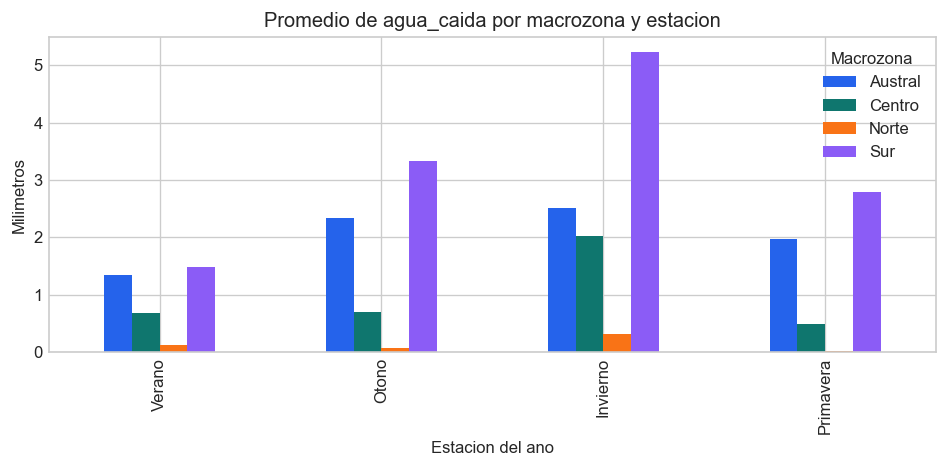

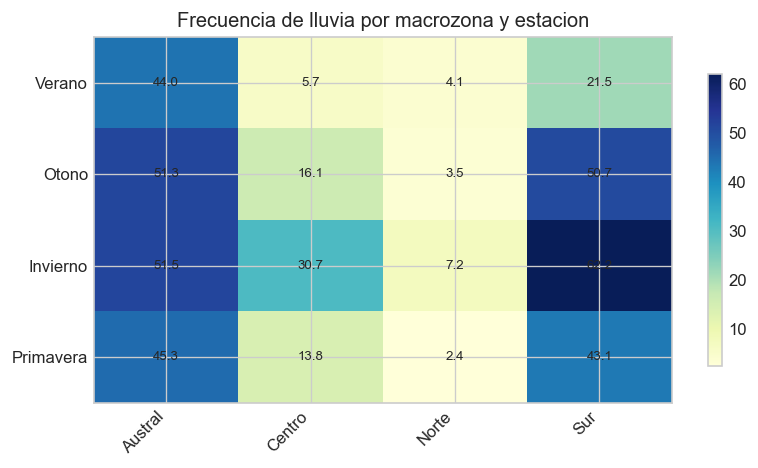

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
patron_macrozona.plot(kind="bar", ax=ax, color=["#2563eb", "#0f766e", "#f97316", "#8b5cf6"])
ax.set_title("Promedio de agua_caida por macrozona y estacion")
ax.set_xlabel("Estacion del ano")
ax.set_ylabel("Milimetros")
ax.legend(title="Macrozona")
plt.tight_layout()
plt.show()

heatmap_df(
    frecuencia_macrozona,
    "Frecuencia de lluvia por macrozona y estacion",
    cmap="YlGnBu",
    figsize=(7, 4),
    decimals=1,
)


**Analisis.** Las nuevas variables permiten distinguir con mayor claridad comportamientos climaticos diferenciados. La macrozona Sur alcanza su mayor precipitacion media en invierno (5.23 mm) y tambien la mayor frecuencia de dias con lluvia (62.18%), mientras que la macrozona Austral mantiene precipitaciones relativamente mas estables durante todo el ano, con frecuencias entre 44% y 51%. La macrozona Centro exhibe una estacionalidad mas marcada, con un aumento claro en invierno (2.02 mm y 30.69% de dias con lluvia), en tanto que la macrozona Norte permanece con niveles bajos en todas las estaciones. En consecuencia, la combinacion entre temporalidad ciclica y agrupacion territorial resume mucho mejor la logica del fenomeno que el uso aislado de `mes` o `region` como variables crudas.


## 3. Transformación 

En esta fase se aplican las transformaciones necesarias para dejar los datos preparados para análisis posteriores, incluyendo codificación de variables, tratamiento de valores faltantes, manejo de outliers y ajustes derivados del preprocesamiento.

### 3.1 Escalamiento